In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from datetime import datetime as dt
from sklearn import metrics
import seaborn as sns
from sklearn.model_selection import cross_val_score
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestClassifier

In [3]:
train=pd.read_csv('data/train.csv',parse_dates=['Date'])
features=pd.read_csv('data/features.csv',parse_dates=['Date'])
stores=pd.read_csv('data/stores.csv')

In [4]:
df1=pd.merge(features,stores,on=['Store'])
df1.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         8190 non-null   int64         
 1   Date          8190 non-null   datetime64[ns]
 2   Temperature   8190 non-null   float64       
 3   Fuel_Price    8190 non-null   float64       
 4   MarkDown1     4032 non-null   float64       
 5   MarkDown2     2921 non-null   float64       
 6   MarkDown3     3613 non-null   float64       
 7   MarkDown4     3464 non-null   float64       
 8   MarkDown5     4050 non-null   float64       
 9   CPI           7605 non-null   float64       
 10  Unemployment  7605 non-null   float64       
 11  IsHoliday     8190 non-null   bool          
 12  Type          8190 non-null   object        
 13  Size          8190 non-null   int64         
dtypes: bool(1), datetime64[ns](1), float64(9), int64(2), object(1)
memory usage: 839.9+ KB


In [6]:
df1.drop(['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5'],axis=1,inplace=True)

In [7]:
df1.head()

,Store,Date,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday,Type,Size
0,1,2010-02-05,42.31,2.572,211.096358,8.106,False,A,151315
1,1,2010-02-12,38.51,2.548,211.242170,8.106,True,A,151315
2,1,2010-02-19,39.93,2.514,211.289143,8.106,False,A,151315
3,1,2010-02-26,46.63,2.561,211.319643,8.106,False,A,151315
4,1,2010-03-05,46.50,2.625,211.350143,8.106,False,A,151315


In [8]:
df1.to_csv('all_features.csv',index=False)

In [9]:
data=pd.merge(train,df1,on=['Date','Store','IsHoliday'])
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106,A,151315


In [10]:
data.shape

(421570, 11)

In [11]:
y=[]
m=[]
d=[]
for dt in data['Date']:
    y.append(dt.year)
    m.append(dt.month)
    d.append(dt.day)

In [12]:
data['Year'] = pd.Series(y)
data['Month'] = pd.Series(m)
data['Day'] = pd.Series(d)

In [13]:
data.drop('Date',axis=1,inplace=True)

In [14]:
data.head()

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size,Year,Month,Day
0,1,1,24924.50,False,42.31,2.572,211.096358,8.106,A,151315,2010,2,5
1,1,1,46039.49,True,38.51,2.548,211.242170,8.106,A,151315,2010,2,12
2,1,1,41595.55,False,39.93,2.514,211.289143,8.106,A,151315,2010,2,19
3,1,1,19403.54,False,46.63,2.561,211.319643,8.106,A,151315,2010,2,26
4,1,1,21827.90,False,46.50,2.625,211.350143,8.106,A,151315,2010,3,5


In [15]:
numeric_var_names=[key for key in dict(data.dtypes) if dict(data.dtypes)[key] in ['float64', 'int64', 'float32', 'int32']]
cat_var_names=[key for key in dict(data.dtypes) if dict(data.dtypes)[key] in ['object', 'O','bool']]

In [16]:
numeric_var_names

['Store',
 'Dept',
 'Weekly_Sales',
 'Temperature',
 'Fuel_Price',
 'CPI',
 'Unemployment',
 'Size',
 'Year',
 'Month',
 'Day']

In [17]:
cat_var_names  

['IsHoliday', 'Type']

In [18]:
data_num=data[numeric_var_names]
data_num.head(5)

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Size,Year,Month,Day
0,1,1,24924.50,42.31,2.572,211.096358,8.106,151315,2010,2,5
1,1,1,46039.49,38.51,2.548,211.242170,8.106,151315,2010,2,12
2,1,1,41595.55,39.93,2.514,211.289143,8.106,151315,2010,2,19
3,1,1,19403.54,46.63,2.561,211.319643,8.106,151315,2010,2,26
4,1,1,21827.90,46.50,2.625,211.350143,8.106,151315,2010,3,5


In [19]:
# Replace negative and 0 as missing
pd.set_option('mode.chained_assignment', None) # For SettingWithCopyWarning
data_num[data_num<=0]=np.nan

In [20]:
data_cat=data[cat_var_names]
data_cat.head(5)

,IsHoliday,Type
0,False,A
1,True,A
2,False,A
3,False,A
4,False,A


### Data Audit Report

In [21]:
# Creating Data audit Report
def var_summary(x):
    return pd.Series([x.count(), x.isnull().sum(), x.sum(), x.mean(), x.median(),  x.std(), x.var(), x.std()/x.mean(), x.min(), x.dropna().quantile(0.01), x.dropna().quantile(0.05),x.dropna().quantile(0.10),x.dropna().quantile(0.25),x.dropna().quantile(0.50),x.dropna().quantile(0.75), x.dropna().quantile(0.90),x.dropna().quantile(0.95), x.dropna().quantile(0.99),x.max()], 
                  index=['N', 'NMISS', 'SUM', 'MEAN','MEDIAN', 'STD', 'VAR', 'CV','MIN', 'P1' , 'P5' ,'P10' ,'P25' ,'P50' ,'P75' ,'P90' ,'P95' ,'P99' ,'MAX'])

data_num.apply(var_summary).T

,N,NMISS,SUM,MEAN,MEDIAN,STD,VAR,CV,MIN,P1,P5,P10,P25,P50,P75,P90,P95,P99,MAX
Store,421570.0,0.0,9.359084e+06,22.200546,22.00000,12.785297,1.634638e+02,0.575900,1.000,1.000000,3.000000,5.000000,11.000000,22.00000,33.000000,40.000000,43.000000,45.000000,45.000000
Dept,421570.0,0.0,1.865882e+07,44.260317,37.00000,30.492054,9.297654e+02,0.688925,1.000,1.000000,4.000000,7.000000,18.000000,37.00000,74.000000,92.000000,95.000000,98.000000,99.000000
Weekly_Sales,420212.0,1358.0,6.737307e+09,16033.114591,7661.70000,22729.492116,5.166298e+08,1.417659,0.010,7.440000,67.551000,311.186000,2120.130000,7661.70000,20271.265000,42922.748000,61275.522000,106566.351400,693099.360000
Temperature,421501.0,69.0,2.533231e+07,60.100233,62.09000,18.432294,3.397495e+02,0.306693,5.540,18.360000,27.310000,33.990000,46.700000,62.09000,74.280000,83.580000,87.270000,92.810000,100.140000
Fuel_Price,421570.0,0.0,1.416908e+06,3.361027,3.45200,0.458515,2.102356e-01,0.136421,2.472,2.565000,2.653000,2.720000,2.933000,3.45200,3.738000,3.917000,4.029000,4.202000,4.468000
CPI,421570.0,0.0,7.217360e+07,171.201947,182.31878,39.159276,1.533449e+03,0.228731,126.064,126.111903,126.496258,128.823806,132.022667,182.31878,212.416993,219.444244,221.941558,225.473509,227.232807
Unemployment,421570.0,0.0,3.355819e+06,7.960289,7.86600,1.863296,3.471872e+00,0.234074,3.879,4.156000,5.326000,5.965000,6.891000,7.86600,8.572000,9.816000,12.187000,14.180000,14.313000
Size,421570.0,0.0,5.764039e+10,136727.915739,140167.00000,60980.583328,3.718632e+09,0.446000,34875.000,34875.000000,39690.000000,39910.000000,93638.000000,140167.00000,202505.000000,204184.000000,206302.000000,219622.000000,219622.000000
Year,421570.0,0.0,8.477640e+08,2010.968591,2011.00000,0.796876,6.350114e-01,0.000396,2010.000,2010.000000,2010.000000,2010.000000,2010.000000,2011.00000,2012.000000,2012.000000,2012.000000,2012.000000,2012.000000
Month,421570.0,0.0,2.718920e+06,6.449510,6.00000,3.243217,1.051846e+01,0.502863,1.000,1.000000,1.000000,2.000000,4.000000,6.00000,9.000000,11.000000,12.000000,12.000000,12.000000


In [22]:
num_summary=data_num.apply(var_summary).T
num_summary.to_csv('num_summary.csv')

In [23]:
def cat_summary(x):
    return pd.Series([x.count(), x.isnull().sum(), x.value_counts()], 
                  index=['N', 'NMISS', 'ColumnsNames'])

cat_summary=data_cat.apply(cat_summary)

In [24]:
cat_summary

,IsHoliday,Type
N,421570,421570
NMISS,0,0
ColumnsNames,IsHoliday False 391909 True 29661 Name...,Type A 215478 B 163495 C 42597 Name:...


### Handling Outlier

In [25]:
#Handling Outliers
def outlier_capping(x):
    x = x.clip(upper=x.quantile(0.99))
    x = x.clip(lower=x.quantile(0.01))
    return x

data_num=data_num.apply(outlier_capping)

### Handling Missing

In [26]:
#Handling missings
def Missing_imputation(x):
    x = x.fillna(x.median())
    return x

data_num=data_num.apply(Missing_imputation)

### Dummy Creation

In [27]:
# An utility function to create dummy variable
def create_dummies( df, colname ):
    col_dummies = pd.get_dummies(df[colname], prefix=colname, drop_first=True)
    df = pd.concat([df, col_dummies], axis=1)
    df.drop( colname, axis = 1, inplace = True )
    return df

In [28]:
for c_feature in ['IsHoliday', 'Type']:
    data_cat.loc[:,c_feature] = data_cat[c_feature].astype('category')
    data_cat = create_dummies(data_cat , c_feature )
    
data_cat.head()

C:\Users\vg606\AppData\Local\Temp\ipykernel_10452\1144814179.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[False, True, False, False, False, ..., False, False, False, False, False]
Length: 421570
Categories (2, bool): [False, True]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  data_cat.loc[:,c_feature] = data_cat[c_feature].astype('category')


,IsHoliday_True,Type_B,Type_C
0,False,False,False
1,True,False,False
2,False,False,False
3,False,False,False
4,False,False,False


### Final file for analysis

In [29]:
data = pd.concat([data_num, data_cat], axis=1)
data.head()

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Size,Year,Month,Day,IsHoliday_True,Type_B,Type_C
0,1,1,24924.50,42.31,2.572,211.096358,8.106,151315,2010,2,5,False,False,False
1,1,1,46039.49,38.51,2.565,211.242170,8.106,151315,2010,2,12,True,False,False
2,1,1,41595.55,39.93,2.565,211.289143,8.106,151315,2010,2,19,False,False,False
3,1,1,19403.54,46.63,2.565,211.319643,8.106,151315,2010,2,26,False,False,False
4,1,1,21827.90,46.50,2.625,211.350143,8.106,151315,2010,3,5,False,False,False


In [30]:
# correlation matrix (ranges from 1 to -1)
corrm=data.corr()
corrm.to_csv('corrm.csv')
corrm

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Size,Year,Month,Day,IsHoliday_True,Type_B,Type_C
Store,1.000000,0.024011,-0.083732,-0.052251,0.064984,-0.210949,0.208671,-0.182881,0.002997,0.001011,-0.000015,-0.000548,-0.233461,0.439004
Dept,0.024011,1.000000,0.143319,0.004383,0.003514,-0.007483,0.007874,-0.003022,0.003688,0.000894,-0.000664,0.000906,-0.029920,0.028344
Weekly_Sales,-0.083732,0.143319,1.000000,0.000576,0.001502,-0.022807,-0.025323,0.252590,-0.009287,0.025578,-0.007982,0.007948,-0.134705,-0.099054
Temperature,-0.052251,0.004383,0.000576,1.000000,0.142011,0.184608,0.095511,-0.059287,0.066476,0.234499,0.025848,-0.156730,-0.107740,0.135709
Fuel_Price,0.064984,0.003514,0.001502,0.142011,1.000000,-0.162609,-0.034938,0.004468,0.780315,-0.042186,0.028013,-0.077839,0.037372,0.001369
CPI,-0.210949,-0.007483,-0.022807,0.184608,-0.162609,1.000000,-0.300190,-0.003307,0.074335,0.005130,0.002701,-0.001934,-0.081883,-0.006557
Unemployment,0.208671,0.007874,-0.025323,0.095511,-0.034938,-0.300190,1.000000,-0.068099,-0.236754,-0.012963,-0.003802,0.010305,-0.013574,0.175291
Size,-0.182881,-0.003022,0.252590,-0.059287,0.004468,-0.003307,-0.068099,1.000000,-0.004975,-0.001210,-0.000386,0.000593,-0.455646,-0.528852
Year,0.002997,0.003688,-0.009287,0.066476,0.780315,0.074335,-0.236754,-0.004975,1.000000,-0.194288,0.005835,-0.056746,-0.000732,0.005244
Month,0.001011,0.000894,0.025578,0.234499,-0.042186,0.005130,-0.012963,-0.001210,-0.194288,1.000000,0.016363,0.123376,0.000019,-0.000092


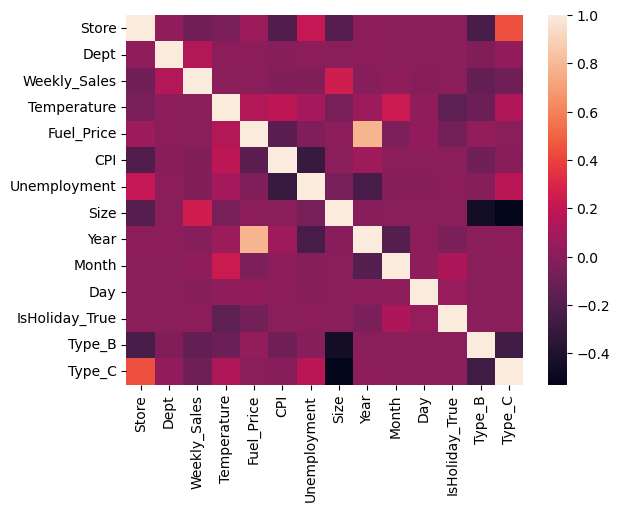

In [31]:
# visualize correlation matrix in Seaborn using a heatmap
sns.heatmap(data.corr())
plt.show()

In [32]:
data.drop('Type_C',axis=1,inplace=True)

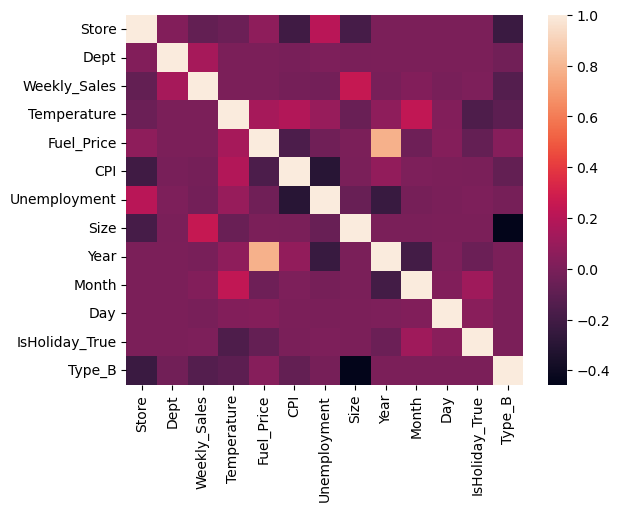

In [33]:
# visualize correlation matrix in Seaborn using a heatmap
sns.heatmap(data.corr())
plt.show()

In [34]:
data.columns

Index(['Store', 'Dept', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI',
       'Unemployment', 'Size', 'Year', 'Month', 'Day', 'IsHoliday_True',
       'Type_B'],
      dtype='object')

### Model Building

In [36]:
lm=smf.ols('Weekly_Sales~Store+Dept+Weekly_Sales+Temperature+Fuel_Price+CPI+Unemployment+Size+Year+Month+Day+IsHoliday_True', data).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:           Weekly_Sales   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.258e+27
Date:                Sat, 07 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:01:36   Log-Likelihood:             6.2807e+06
No. Observations:              421570   AIC:                        -1.256e+07
Df Residuals:                  421557   BIC:                        -1.256e+07
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               6.08

In [37]:
data.drop('Type_B',axis=1,inplace=True)

In [38]:
X=data[data.columns.difference(['Weekly_Sales'])]
y=data['Weekly_Sales']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Decision Tree

In [40]:
from sklearn.tree import DecisionTreeRegressor  
from sklearn.model_selection import cross_val_predict

In [41]:
regressor = DecisionTreeRegressor(max_depth=5,random_state=0)  
regressor.fit(X_train, y_train) 

DecisionTreeRegressor(max_depth=5, random_state=0)

In [42]:
pred=regressor.predict(X_train)
y_pred=regressor.predict(X_test)

In [43]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 9145.257041898783
Mean Squared Error: 192332068.63084176
Root Mean Squared Error: 13868.383778611038


In [44]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 9177.598768122753
Mean Squared Error: 193167074.29474044
Root Mean Squared Error: 13898.455824110117


In [45]:
from sklearn.metrics import r2_score

print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.5539828660028754
R-squared for Test: 0.5528359126879683


### Tuning a regression tree

In [46]:
# list of values to try
max_depth_range = range(5, 15)

# list to store the average RMSE for each value of max_depth
RMSE_Scores = []
MSE_Scores = []

# use LOOCV with each value of max_depth
for depth in max_depth_range:
    treereg = DecisionTreeRegressor(max_depth=depth, random_state=345)
    
    MSE_scores = cross_val_score(treereg, X_train, y_train, scoring='neg_mean_squared_error')
    
    RMSE_Scores.append(np.mean(np.sqrt(-MSE_scores)))
    MSE_Scores.append(MSE_scores)

In [47]:
print (RMSE_Scores)

[np.float64(13879.719881611905), np.float64(11056.966940995324), np.float64(10071.28342663819), np.float64(9162.092645626446), np.float64(8323.610416874799), np.float64(7402.689432054516), np.float64(6537.198777528016), np.float64(5839.292861122634), np.float64(5196.5718956209375), np.float64(4737.93020445316)]


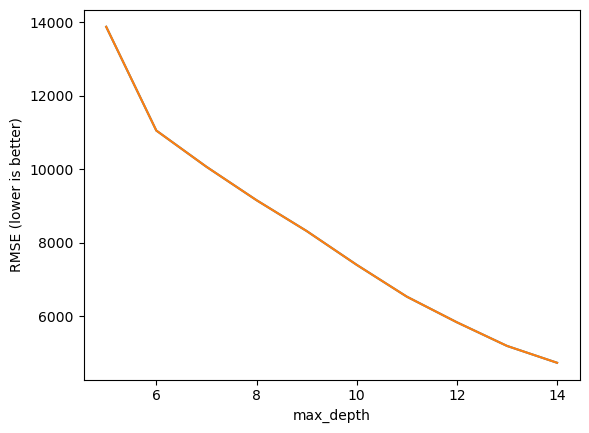

In [49]:
# plot max_depth (x-axis) versus RMSE (y-axis)
plt.plot(max_depth_range, RMSE_Scores)
plt.xlabel('max_depth')
plt.ylabel('RMSE (lower is better)')
plt.show()

### Building Final Decision Tree Model

In [50]:
# max_depth=11 was best, so fit a tree using that parameter
treereg = DecisionTreeRegressor(max_depth=14, random_state=345)
treereg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=14, random_state=345)

In [51]:
treereg.feature_importances_

array([2.36179525e-02, 7.28499939e-03, 6.83358021e-01, 1.68787384e-03,
       1.38719984e-03, 1.69391383e-02, 1.89252892e-01, 6.36291334e-02,
       4.87481053e-03, 7.57401979e-03, 3.93959683e-04])

In [52]:
# "Gini importance" of each feature: the (normalized) total reduction of error brought by that feature
pd.DataFrame({'feature':data.columns.difference(['Weekly_Sales']), 'importance':treereg.feature_importances_})

,feature,importance
0,CPI,0.023618
1,Day,0.007285
2,Dept,0.683358
3,Fuel_Price,0.001688
4,IsHoliday_True,0.001387
5,Month,0.016939
6,Size,0.189253
7,Store,0.063629
8,Temperature,0.004875
9,Unemployment,0.007574


## Creating a tree diagram

In [53]:
# create a Graphviz file
from sklearn.tree import export_graphviz
export_graphviz(treereg, out_file='tree_vehicles.png', feature_names=data.columns.difference(['Weekly_Sales']))

## Making predictions

In [54]:
pred=treereg.predict(X_train)
y_pred=treereg.predict(X_test)

In [55]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 2041.5165842990527
Mean Squared Error: 15729169.345961288
Root Mean Squared Error: 3966.001682546452


In [56]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 2355.453541097146
Mean Squared Error: 21290797.958956957
Root Mean Squared Error: 4614.195266669688


In [57]:
print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.9635241326015869
R-squared for Test: 0.9507137524745278


# Random Forest (RF)

In [58]:
from sklearn.ensemble import RandomForestRegressor

In [59]:
rfr = RandomForestRegressor(max_depth=5,n_estimators=20, random_state=0)  
rfr.fit(X_train, y_train)  
pred = rfr.predict(X_train) 

In [60]:
y_pred= rfr.predict(X_test)

In [61]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 9112.615193344995
Mean Squared Error: 191590025.02633145
Root Mean Squared Error: 13841.604857325305


In [62]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 9147.59553607459
Mean Squared Error: 192546102.52754837
Root Mean Squared Error: 13876.098245816378


In [63]:
print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.5557036615214834
R-squared for Test: 0.5542734054622249


### Tuning a Random Forest

In [64]:
from sklearn.model_selection import GridSearchCV

In [65]:
param_grid={'max_depth': range(5,15),
            'n_estimators': (10, 50)}

In [66]:
# Perform Grid-Search
gsc = GridSearchCV(estimator=RandomForestRegressor(),param_grid=param_grid, verbose=0, n_jobs=-1)
    
grid_result = gsc.fit(X_train, y_train)

In [67]:
grid_result.best_score_

np.float64(0.9605896048050757)

In [68]:
grid_result.best_params_

{'max_depth': 14, 'n_estimators': 50}

### Building Final Random Forest Model

In [69]:
rfr = RandomForestRegressor(max_depth=14,n_estimators=50, random_state=0)
rfr.fit(X_train, y_train) 

RandomForestRegressor(max_depth=14, n_estimators=50, random_state=0)

In [70]:
pred = rfr.predict(X_train)
y_pred = rfr.predict(X_test)

In [71]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 1921.4216533167446
Mean Squared Error: 13259126.111445336
Root Mean Squared Error: 3641.3082966765305


In [72]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 2158.2578133613965
Mean Squared Error: 17123165.549061134
Root Mean Squared Error: 4138.014686907374


In [73]:
from sklearn.metrics import r2_score

print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.9692521508782599
R-squared for Test: 0.9603614398437507


# Gradient Boosting (GBM)

In [74]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import ShuffleSplit

In [75]:
gbrt=GradientBoostingRegressor()
gbrt.fit(X_train, y_train)

GradientBoostingRegressor()

In [76]:
pred=gbrt.predict(X_train)
y_pred=gbrt.predict(X_test)

In [77]:
#One of the benefits of growing trees is that we can understand how important each of the features are
print(gbrt.feature_importances_)

[8.41962440e-03 5.80770903e-04 7.56893138e-01 1.33860504e-06
 1.94284217e-04 2.50511115e-03 1.94325834e-01 3.53524270e-02
 4.90632028e-04 1.20221093e-03 3.46283629e-05]


In [78]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 6596.780468548503
Mean Squared Error: 101324484.21621586
Root Mean Squared Error: 10066.006368774852


In [79]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 6661.58543014956
Mean Squared Error: 103823313.13689311
Root Mean Squared Error: 10189.372558548102


In [80]:
from sklearn.metrics import r2_score

print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.7650290127092899
R-squared for Test: 0.7596585379259214


### Tuning a Gradient Boosting Model (GBM)

In [81]:
param_grid={'learning_rate' : [0.02,0.05,0.1,0.01],# 0.02,0.05,0.1],
            'max_depth' : [4,5,6]}# 5,6]

In [82]:
# Perform Grid-Search
gbr = GridSearchCV(estimator=GradientBoostingRegressor(),param_grid=param_grid)
    
grid_result = gbr.fit(X_train, y_train)

In [83]:
grid_result.best_score_

np.float64(0.9102735335684887)

In [84]:
grid_result.best_params_

{'learning_rate': 0.1, 'max_depth': 6}

### Building Final Gradient Boosting Model

In [85]:
gbrt=GradientBoostingRegressor(learning_rate=0.01, max_depth=6)
gbrt.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.01, max_depth=6)

In [86]:
pred=gbrt.predict(X_train)
y_pred=gbrt.predict(X_test)

In [87]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 8783.487998672386
Mean Squared Error: 157159224.44013366
Root Mean Squared Error: 12536.316222883564


In [88]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 8823.577123391799
Mean Squared Error: 159398914.9682369
Root Mean Squared Error: 12625.328311304895


In [89]:
print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.6355485210293269
R-squared for Test: 0.6310061091387532


# XGBOOST

In [90]:
import xgboost as xgb
import warnings

In [91]:
warnings.filterwarnings("ignore", category=FutureWarning)
xg_reg = xgb.XGBRegressor(objective='reg:squarederror')
xg_reg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [92]:
pred=xg_reg.predict(X_train)
y_pred=xg_reg.predict(X_test)

In [93]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 2767.488903875319
Mean Squared Error: 20408023.43704571
Root Mean Squared Error: 4517.524038347301


In [94]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 2856.8736823375125
Mean Squared Error: 22254882.219408434
Root Mean Squared Error: 4717.508051864716


In [95]:
print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.9526738926652523
R-squared for Test: 0.9484819856996224


### Tuning a XGBoost Model

In [96]:
xgb1 = xgb.XGBRegressor(objective='reg:squarederror')

In [97]:
parameters = {'learning_rate': [0.01,0.1], #so called `eta` value
              'max_depth': [4,5,6]}

In [98]:
xgb_grid = GridSearchCV(xgb1,parameters,n_jobs = 5,verbose=True)

grid_result = xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


In [99]:
print(xgb_grid.best_score_)

0.9108366261665445


In [100]:
print(xgb_grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 6}


### Building Final XGBoost Model

In [101]:
xg_reg = xgb.XGBRegressor(learning_rate=0.1, max_depth=6,objective='reg:squarederror')
xg_reg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [102]:
pred=xg_reg.predict(X_train)
y_pred=xg_reg.predict(X_test)

In [103]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 3743.863168416007
Mean Squared Error: 37531186.10453154
Root Mean Squared Error: 6126.270162548461


In [104]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 3814.9276965765757
Mean Squared Error: 39642386.9466676
Root Mean Squared Error: 6296.220052274824


In [105]:
print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.9129653615176083
R-squared for Test: 0.9082315045532597


# KNN

In [106]:
from sklearn import neighbors
from sklearn.metrics import mean_squared_error 
from math import sqrt

In [107]:
knn = neighbors.KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsRegressor()

In [108]:
pred=knn.predict(X_train)
y_pred=knn.predict(X_test)

In [109]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 8650.11614599385
Mean Squared Error: 176182583.32617974
Root Mean Squared Error: 13273.378745676617


In [110]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 10535.641958266482
Mean Squared Error: 260645424.34379593
Root Mean Squared Error: 16144.516850739012


In [111]:
from sklearn.metrics import r2_score

print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.5914334440702241
R-squared for Test: 0.39662971179594975


### Tuning a KNN Model

In [112]:
rmse_val = [] #to store rmse values for different k
for K in range(20):
    K = K+1
    model = neighbors.KNeighborsRegressor(n_neighbors = K)

    model.fit(X_train, y_train)  #fit the model
    y_pred=model.predict(X_test) #make prediction on test set
    error = sqrt(mean_squared_error(y_test,y_pred)) #calculate rmse
    rmse_val.append(error) #store rmse values
    print('RMSE value for k= ' , K , 'is:', error)

RMSE value for k=  1 is: 22339.479388002816
RMSE value for k=  2 is: 18695.24319614872
RMSE value for k=  3 is: 17373.98520630404
RMSE value for k=  4 is: 16619.98088735237
RMSE value for k=  5 is: 16144.516850739012
RMSE value for k=  6 is: 15870.50396562844
RMSE value for k=  7 is: 15688.270590334869
RMSE value for k=  8 is: 15572.21278447079
RMSE value for k=  9 is: 15496.253775001587
RMSE value for k=  10 is: 15441.950806371728
RMSE value for k=  11 is: 15406.248796126521
RMSE value for k=  12 is: 15376.427078092327
RMSE value for k=  13 is: 15350.65188139058
RMSE value for k=  14 is: 15338.384373233486
RMSE value for k=  15 is: 15333.958453882047
RMSE value for k=  16 is: 15331.556727687035
RMSE value for k=  17 is: 15328.642618142265
RMSE value for k=  18 is: 15323.193177368028
RMSE value for k=  19 is: 15322.29131951377
RMSE value for k=  20 is: 15325.32124438657


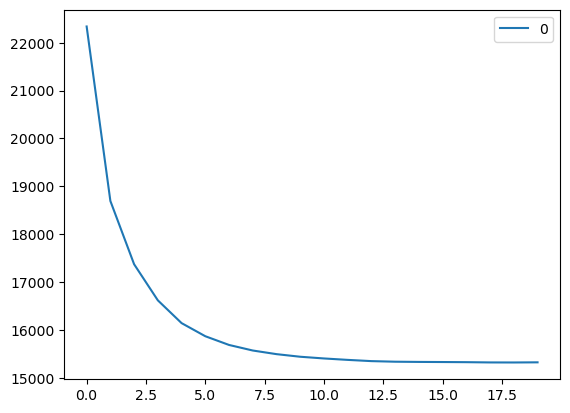

In [117]:
#plotting the rmse values against k values
curve = pd.DataFrame(rmse_val) #elbow curve 
curve.plot()
plt.show()

### Building Final KNN Model

In [118]:
knn = neighbors.KNeighborsRegressor(n_neighbors=9)
knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=9)

In [119]:
pred=knn.predict(X_train)
y_pred=knn.predict(X_test)

In [120]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 9070.016699212581
Mean Squared Error: 190647299.02461982
Root Mean Squared Error: 13807.508791401142


In [121]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 10178.299509280741
Mean Squared Error: 240133881.05925095
Root Mean Squared Error: 15496.253775001587


In [122]:
print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.5578898385455295
R-squared for Test: 0.44411205611204074


# Neural Network

In [125]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from scikeras.wrappers import KerasRegressor

In [129]:
def build_regressor():
    regressor = Sequential()
    regressor.add(Dense(units=1, input_dim=11))
    regressor.add(Dense(units=1))
    regressor.compile(optimizer='adam', loss='mean_squared_error',  metrics=['mae'])
    return regressor

In [130]:
regressor = KerasRegressor(build_fn=build_regressor, batch_size=256,epochs=10)

In [131]:
results=regressor.fit(X_train,y_train)

C:\Users\vg606\anaconda3\Lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
C:\Users\vg606\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 700us/step - loss: 422846048.0000 - mae: 13876.6982   
Epoch 2/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 701us/step - loss: 406058464.0000 - mae: 13897.8555
Epoch 3/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 696us/step - loss: 404839904.0000 - mae: 13929.5781
Epoch 4/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 692us/step - loss: 403884480.0000 - mae: 13969.3994
Epoch 5/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 698us/step - loss: 403336416.0000 - mae: 14007.6045
Epoch 6/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 696us/step - loss: 402930464.0000 - mae: 14033.3799
Epoch 7/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step - loss: 402707616.0000 - mae: 14052.3857
Epoch 8/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 697us/step - loss: 402436960.0000 - mae: 14064.3857
Epoch 9/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 717us/step - loss: 402166688.0000 - mae: 14070.7627
Epoch 10/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 789us/step - loss: 401874080.0000 - mae: 14072.0654


In [132]:
pred= regressor.predict(X_train)
y_pred= regressor.predict(X_test)

1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 445us/step
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step


In [133]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 14047.566196587046
Mean Squared Error: 401589471.7567917
Root Mean Squared Error: 20039.697396836902


In [134]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 14040.59548726046
Mean Squared Error: 402181555.48080444
Root Mean Squared Error: 20054.464726858318


In [135]:
print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.0687159634300265
R-squared for Test: 0.06898652968207275


### Voting Regressor

In [136]:
from sklearn.tree import DecisionTreeRegressor  
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import VotingRegressor
import warnings

In [137]:
warnings.filterwarnings("ignore", category=FutureWarning)  # Ignore FutureWarning
reg1 = DecisionTreeRegressor(max_depth=14, random_state=345)
reg2 = RandomForestRegressor(max_depth=14,n_estimators=50, random_state=0)
reg3 = xgb.XGBRegressor(learning_rate=0.1, max_depth=6,objective='reg:squarederror')
ereg = VotingRegressor(estimators=[('gb', reg1), ('rf', reg2), ('xg', reg3)])
ereg = ereg.fit(X_train, y_train)

In [138]:
pred= ereg.predict(X_train)
y_pred= ereg.predict(X_test)

In [139]:
print('Train : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_train, pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_train, pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_train, pred)))

Train : 
Mean Absolute Error: 2273.848830972961
Mean Squared Error: 15673404.312892834
Root Mean Squared Error: 3958.9650557807195


In [140]:
print('Test : ')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Test : 
Mean Absolute Error: 2447.3945736764276
Mean Squared Error: 19074838.78803073
Root Mean Squared Error: 4367.475104454601


In [141]:
print("R-squared for Train:",r2_score(y_train, pred))
print("R-squared for Test:",r2_score(y_test, y_pred))

R-squared for Train: 0.9636534514427115
R-squared for Test: 0.9558434950241096


# Save Model

In [142]:
import joblib
# Saving model to disk of random forest
joblib.dump(ereg, 'model.pkl')

['model.pkl']

# Load Model and Predict

In [147]:
import joblib
model=joblib.load('model.pkl')
model.predict([[211.0963582,5,1,2.572,0,2,151315,1,42.31,0,2010]])

C:\Users\vg606\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
C:\Users\vg606\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([21619.29760455])

In [146]:
X_train.columns

Index(['CPI', 'Day', 'Dept', 'Fuel_Price', 'IsHoliday_True', 'Month', 'Size',
       'Store', 'Temperature', 'Unemployment', 'Year'],
      dtype='object')